# Airline Passenger Satisfaction — Tabular ML (EDA → Model Selection → Tuning → Final)

Notebook này làm **đầy đủ quy trình chọn mô hình hợp lý**:
1) EDA  
2) Baseline (Dummy)  
3) Model zoo (CV) — chạy nhiều model để so sánh công bằng  
4) Chọn model theo tiêu chí (ưu tiên F1, tie-break ROC-AUC, xét std) + **log chọn/loại**  
5) Tuning model được chọn  
6) Train full → Evaluate test  
7) Lưu artifacts + features theo yêu cầu nộp bài

In [20]:
# from google.colab import drive
# drive.mount('/content/drive')

In [21]:
# =========================
# 0) Config (hỗ trợ --out_dir)
# =========================
import os, json, shlex, argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Nếu chạy trong notebook: chỉnh dòng này để truyền flag kiểu CLI
# Ví dụ:
#   CLI_ARGS = "--out_dir outputs/run1 --data_dir data --fast"
# CLI_ARGS = "--out_dir ../outputs --eval_knn"  # để trống => dùng mặc định
CLI_ARGS = "--out_dir /content/drive/MyDrive/ML_Project/runs/exp1/ --eval_knn --knn_sample_n 999999999"

def parse_args(cli_args: str = ""):
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--out_dir", type=str, default=".", help="Thư mục lưu outputs (artifacts/features/eda_outputs).")
    parser.add_argument("--data_dir", type=str, default="data", help="Thư mục chứa train.csv/test.csv (mặc định ./data).")
    parser.add_argument("--fast", action="store_true", help="Chạy nhẹ hơn (ít fold, ít model, bỏ tuning).")
    parser.add_argument("--eval_knn", action="store_true", help="Bật thử KNN (mặc định: OFF vì nặng).")
    parser.add_argument("--knn_sample_n", type=int, default=20000, help="Số mẫu dùng để CV cho KNN (subsample).")
    parser.add_argument("--seed", type=int, default=42, help="Random seed.")
    if cli_args.strip() == "":
        # Notebook kernel có nhiều argv rác → parse_known_args cho an toàn
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args(shlex.split(cli_args))
    return args

args = parse_args(CLI_ARGS)

RANDOM_STATE = int(args.seed)

# --- START: Set Global Seed ---
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to: {seed}")

set_seed(RANDOM_STATE)
# --- END: Set Global Seed ---

TARGET_COL = "satisfaction"
DROP_COLS_CANDIDATES = ["Unnamed: 0", "id"]

FAST_MODE = bool(args.fast)
EVAL_KNN = bool(args.eval_knn)
KNN_SAMPLE_N = int(args.knn_sample_n)

# Resolve dirs
OUT_DIR = Path(args.out_dir).expanduser().resolve()
DATA_DIR = Path(args.data_dir).expanduser()
if not DATA_DIR.is_absolute():
    DATA_DIR = (Path.cwd() / DATA_DIR).resolve()

ARTIFACTS_DIR = OUT_DIR / "artifacts"
FEATURES_DIR  = OUT_DIR / "features"
EDA_DIR       = OUT_DIR / "eda_outputs"

for d in [OUT_DIR, ARTIFACTS_DIR, FEATURES_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_MODE:", FAST_MODE)
print("OUT_DIR:", OUT_DIR)
print("DATA_DIR:", DATA_DIR)
print("EVAL_KNN:", EVAL_KNN, "| KNN_SAMPLE_N:", KNN_SAMPLE_N)

Global seed set to: 42
FAST_MODE: False
OUT_DIR: /content/drive/MyDrive/ML_Project/runs/exp1
DATA_DIR: /content/data
EVAL_KNN: True | KNN_SAMPLE_N: 999999999


In [22]:
# =========================
# 1) Download data từ Kaggle bằng kagglehub (tuỳ chọn)
# =========================
# Nếu bạn đã có sẵn train.csv/test.csv trong DATA_DIR thì có thể bỏ qua cell này.

try:
    import kagglehub
    import shutil

    source_path = Path(kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction"))

    DATA_DIR.mkdir(parents=True, exist_ok=True)

    for item in source_path.iterdir():
        destination = DATA_DIR / item.name
        if destination.exists():
            if destination.is_dir():
                shutil.rmtree(destination)
            else:
                destination.unlink()
        shutil.move(str(item), str(destination))

    print("Downloaded from:", source_path)
    print("Moved dataset files to:", DATA_DIR.resolve())
except Exception as e:
    print("Không chạy được kagglehub (có thể bạn chưa cài hoặc đang offline).")
    print("Nếu cần, cài: pip install kagglehub")
    print("Lỗi:", e)

Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
Không chạy được kagglehub (có thể bạn chưa cài hoặc đang offline).
Nếu cần, cài: pip install kagglehub
Lỗi: [Errno 30] Read-only file system: '/kaggle/input/airline-passenger-satisfaction/train.csv'


In [23]:
# =========================
# 2) Load data
# =========================
assert DATA_DIR.exists(), f"Không thấy DATA_DIR: {DATA_DIR}"

csvs = list(DATA_DIR.glob("*.csv"))
print("CSV in DATA_DIR:", [p.name for p in csvs])

train_path = DATA_DIR / "train.csv"
test_path  = DATA_DIR / "test.csv"

if not train_path.exists() or not test_path.exists():
    # fallback theo tên chứa train/test
    for p in csvs:
        name = p.name.lower()
        if "train" in name:
            train_path = p
        if "test" in name:
            test_path = p

assert train_path.exists(), f"Không tìm thấy train.csv trong {DATA_DIR}"
assert test_path.exists(), f"Không tìm thấy test.csv trong {DATA_DIR}"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape, "|", train_path)
print("Test :", test_df.shape, "|", test_path)
train_df.head()

CSV in DATA_DIR: ['test.csv', 'train.csv']
Train: (103904, 25) | /content/data/train.csv
Test : (25976, 25) | /content/data/test.csv


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 3) EDA

In [24]:
# 3.1) Info + describe
display(train_df.info())
display(train_df.describe(include="all").T.head(40))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0


Target unique values: ['neutral or dissatisfied' 'satisfied']


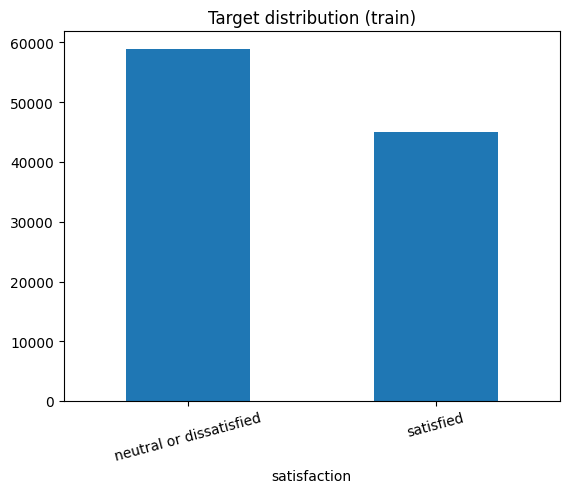

,proportion
satisfaction,
neutral or dissatisfied,0.566667
satisfied,0.433333


In [25]:
# 3.2) Target distribution
print("Target unique values:", train_df[TARGET_COL].unique())
target_map = {"neutral or dissatisfied": 0, "satisfied": 1}

fig = plt.figure()
train_df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target distribution (train)")
plt.xticks(rotation=15)
plt.show()

display(train_df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

In [26]:
# 3.3) Missing values (train/test)
missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test  = test_df.isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_train": missing_train,
    "missing_test": missing_test
})
missing_summary["missing_rate_train"] = missing_summary["missing_train"] / len(train_df)
missing_summary["missing_rate_test"]  = missing_summary["missing_test"] / len(test_df)

display(missing_summary[(missing_summary["missing_train"] + missing_summary["missing_test"]) > 0])

,missing_train,missing_test,missing_rate_train,missing_rate_test
Arrival Delay in Minutes,310,83,0.002984,0.003195


In [27]:
# 3.4) Categorical vs Numeric + split X/y
drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]
print("Drop cols:", drop_cols)

X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)
y_full = train_df[TARGET_COL].map(target_map)

X_test = test_df.drop(columns=[TARGET_COL] + drop_cols)
y_test = test_df[TARGET_COL].map(target_map)

cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_full.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols[:10], "... total:", len(num_cols))

Drop cols: ['Unnamed: 0', 'id']
Categorical cols: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeric cols: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment'] ... total: 18


In [28]:
# 3.5) Insight nhanh: tỉ lệ satisfied theo nhóm categorical
for c in cat_cols:
    print("\n===", c, "===")
    display(train_df[c].value_counts())
    display(pd.crosstab(train_df[c], train_df[TARGET_COL], normalize="index").round(3))


=== Gender ===


,count
Gender,
Female,52727
Male,51177


satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,0.573,0.427
Male,0.561,0.439



=== Customer Type ===


,count
Customer Type,
Loyal Customer,84923
disloyal Customer,18981


...

,count
Type of Travel,
Business travel,71655
Personal Travel,32249


satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,0.417,0.583
Personal Travel,0.898,0.102



=== Class ===


,count
Class,
Business,49665
Eco,46745
Eco Plus,7494


satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,0.306,0.694
Eco,0.814,0.186
Eco Plus,0.754,0.246


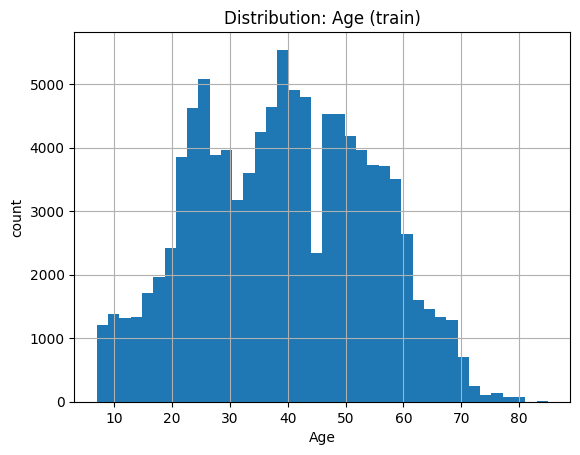

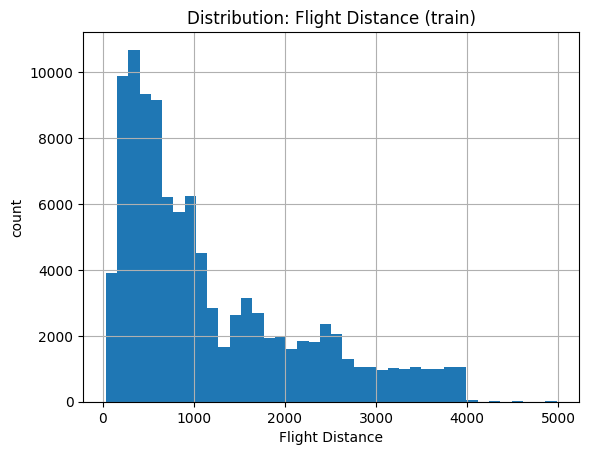

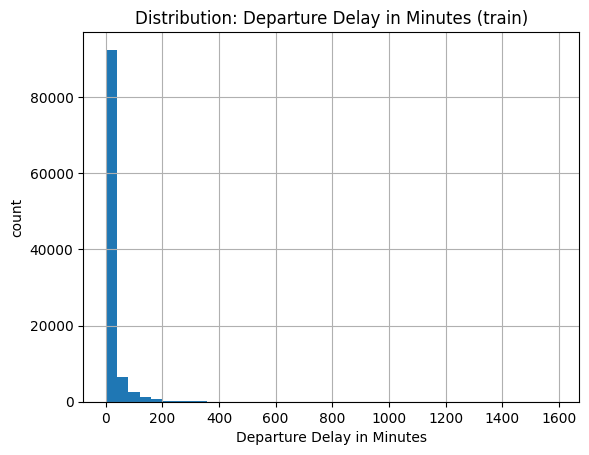

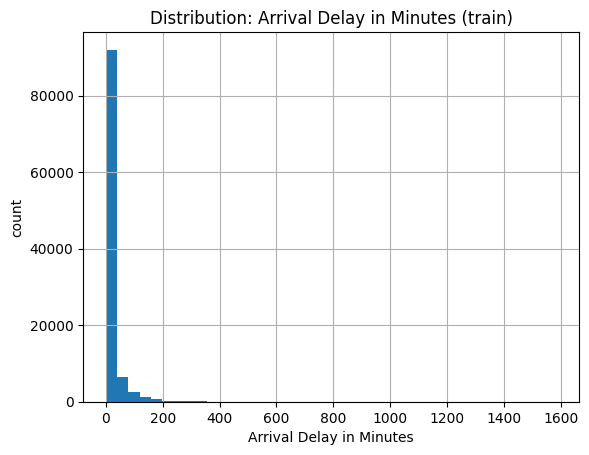

In [29]:
# 3.6) Histogram vài cột số
num_to_plot = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
num_to_plot = [c for c in num_to_plot if c in train_df.columns]

for c in num_to_plot:
    fig = plt.figure()
    train_df[c].hist(bins=40)
    plt.title(f"Distribution: {c} (train)")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

In [30]:
# 3.7) Correlation numeric vs target
tmp = train_df.copy()
tmp["target_bin"] = tmp[TARGET_COL].map(target_map)

corr = tmp.drop(columns=[TARGET_COL]).corr(numeric_only=True)["target_bin"].sort_values(ascending=False)
display(corr.head(15).to_frame("corr_with_target"))
display(corr.tail(15).to_frame("corr_with_target"))

,corr_with_target
target_bin,1.000000
Online boarding,0.503557
Inflight entertainment,0.398059
Seat comfort,0.349459
On-board service,0.322383
Leg room service,0.313131
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749


,corr_with_target
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749
Inflight service,0.244741
Checkin service,0.236174
Food and drink,0.209936
Ease of Online booking,0.171705
Age,0.137167
id,0.013734


## 4) Preprocess + Pipeline

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD an toàn: tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        if n_comp < 1:
            raise ValueError(f"Không thể SVD vì n_features={n_features}")
        self.n_components_ = n_comp
        self.svd_ = TruncatedSVD(n_components=self.n_components_, random_state=self.random_state)
        self.svd_.fit(X, y)
        return self

    def transform(self, X):
        return self.svd_.transform(X)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

def build_preprocessor(scaler: str | None = "standard") -> ColumnTransformer:
    if scaler in (None, "none"):
        scaler_obj = "passthrough"
    elif scaler == "standard":
        scaler_obj = StandardScaler()
    elif scaler == "minmax":
        scaler_obj = MinMaxScaler()
    else:
        raise ValueError("scaler must be one of: standard, minmax, none")

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_obj),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop", sparse_threshold=0.3)

    return pre

def make_pipeline(model, scaler="standard", use_svd=False, n_components=32):
    steps = [("preprocess", build_preprocessor(scaler=scaler))]
    if use_svd:
        steps.append(("svd", SafeTruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

## 5) Baseline + Model Zoo (CV) + Log chọn/loại

In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
import numpy as np

def cv_summary(pipe, X, y, cv, scoring):
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    out = {}
    for k in scoring.keys():
        out[f"{k}_mean"] = float(np.mean(res[f"test_{k}"]))
        out[f"{k}_std"]  = float(np.std(res[f"test_{k}"]))
    return out

# CV folds
n_splits = 3 if FAST_MODE else 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {"acc": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

# 5.1) Baseline
baseline_pipe = make_pipeline(DummyClassifier(strategy="most_frequent"), scaler="none", use_svd=False)
print(f"Running baseline CV ({n_splits} folds) on FULL train...")
baseline_stats = cv_summary(baseline_pipe, X_full, y_full, cv=cv, scoring=scoring)
baseline_stats

Running baseline CV (5 folds) on FULL train...


{'acc_mean': 0.5666673081240133,
 'acc_std': 8.341261236699538e-06,
 'f1_mean': 0.0,
 'f1_std': 0.0,
 'roc_auc_mean': 0.5,
 'roc_auc_std': 0.0}

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# 5.2) Model zoo (FULL CV)
models_fullcv = {}

models_fullcv["LogReg (std)"] = make_pipeline(LogisticRegression(max_iter=3000), scaler="standard")
models_fullcv["LinearSVC calibrated (std)"] = make_pipeline(
    CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3),
    scaler="standard"
)
models_fullcv["RandomForest"] = make_pipeline(
    RandomForestClassifier(n_estimators=300 if not FAST_MODE else 200, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none"
)
models_fullcv["ExtraTrees"] = make_pipeline(
    ExtraTreesClassifier(n_estimators=600 if not FAST_MODE else 300, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none"
)
models_fullcv["HistGradientBoosting"] = make_pipeline(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    scaler="none"
)
models_fullcv["LogReg + SVD(32)"] = make_pipeline(
    LogisticRegression(max_iter=3000),
    scaler="standard",
    use_svd=True,
    n_components=32
)

# FAST_MODE: giảm bớt model nếu muốn
if FAST_MODE:
    keep = ["LogReg (std)", "RandomForest", "HistGradientBoosting"]
    models_fullcv = {k: models_fullcv[k] for k in keep}

print("Evaluating", len(models_fullcv), "models with", n_splits, "fold CV on FULL train...")

rows = []
for name, pipe in models_fullcv.items():
    stats = cv_summary(pipe, X_full, y_full, cv=cv, scoring=scoring)
    rows.append({
        "model": name,
        "eval_data": "full_train",
        "n_samples": int(len(X_full)),
        "cv_folds": int(n_splits),
        **stats
    })

zoo_df = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
display(zoo_df)

Evaluating 6 models with 5 fold CV on FULL train...


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366
1,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404
2,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457
3,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
4,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
5,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955


In [34]:
# 5.3) KNN (tuỳ chọn) — chạy CV trên SUBSAMPLE để tránh quá chậm
from sklearn.neighbors import KNeighborsClassifier

zoo_df_all = zoo_df.copy()

if EVAL_KNN:
    n_take = min(KNN_SAMPLE_N, len(X_full))
    if n_take < len(X_full):
        X_knn, _, y_knn, _ = train_test_split(
            X_full, y_full,
            train_size=n_take,
            stratify=y_full,
            random_state=RANDOM_STATE
        )
    else:
        X_knn, y_knn = X_full, y_full

    knn_folds = n_splits if FAST_MODE else 3
    knn_cv = StratifiedKFold(n_splits=knn_folds, shuffle=True, random_state=RANDOM_STATE)

    knn_pipe = make_pipeline(
        KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
        scaler="standard",
        use_svd=True,
        n_components=32
    )

    print(f"Evaluating KNN with {knn_folds}-fold CV on SUBSAMPLE n={n_take} ...")
    knn_stats = cv_summary(knn_pipe, X_knn, y_knn, cv=knn_cv, scoring=scoring)

    knn_row = {
        "model": "KNN(k=15)+SVD(32)",
        "eval_data": "full_train",
        "n_samples": int(n_take),
        "cv_folds": int(knn_folds),
        **knn_stats
    }
    zoo_df_all = pd.concat([zoo_df_all, pd.DataFrame([knn_row])], ignore_index=True)

display(zoo_df_all.sort_values(["eval_data", "f1_mean"], ascending=[True, False]).reset_index(drop=True))

Evaluating KNN with 5-fold CV on SUBSAMPLE n=103904 ...


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366
1,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404
2,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457
3,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
4,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
5,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955
6,KNN(k=15)+SVD(32),subsample,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243


In [ ]:
# 5.4) Model selection log (rõ đã thử bao nhiêu model + lý do chọn/loại)
baseline_f1  = baseline_stats["f1_mean"]
baseline_auc = baseline_stats["roc_auc_mean"]

log_df = zoo_df_all.copy()
log_df["f1_gain_vs_baseline"]  = log_df["f1_mean"] - baseline_f1
log_df["auc_gain_vs_baseline"] = log_df["roc_auc_mean"] - baseline_auc

# Chỉ chọn best từ nhóm full_train (điều kiện đánh giá công bằng)
full = log_df[log_df["eval_data"] == "full_train"].copy()
full = full.sort_values(["f1_mean", "roc_auc_mean"], ascending=False).reset_index(drop=True)
full["rank_fullcv"] = np.arange(1, len(full) + 1)

best_name = full.loc[0, "model"]
best_f1 = float(full.loc[0, "f1_mean"])
best_auc = float(full.loc[0, "roc_auc_mean"])

log_df["decision"] = "rejected"
log_df.loc[log_df["model"] == best_name, "decision"] = "SELECTED (best full CV)"
log_df.loc[log_df["eval_data"] != "full_train", "decision"] = "explored (subsample only)"

def reason(row):
    if row["model"] == best_name:
        return "F1 cao nhất (full CV), tie-break ROC-AUC; chọn để tuning & final."
    if row["eval_data"] != "full_train":
        return "Model nặng nên chỉ chạy subsample để chứng minh đã thử, không dùng để chọn cuối."

    r = []
    delta_f1 = best_f1 - float(row["f1_mean"])
    delta_auc = best_auc - float(row["roc_auc_mean"])

    if delta_f1 > 0.01:
        r.append("F1 thấp hơn rõ rệt so với best (>0.01)")
    elif delta_f1 > 0:
        r.append("F1 thấp hơn nhẹ so với best")

    if delta_auc > 0.005:
        r.append("ROC-AUC thấp hơn đáng kể")

    if float(row.get("f1_std", 0.0)) > float(full["f1_std"].median()) + 0.005:
        r.append("độ ổn định thấp hơn (f1_std cao)")

    if not r:
        r.append("sát best nhưng thua tie-break ROC-AUC hoặc độ ổn định")

    return "; ".join(r)

log_df["reason"] = log_df.apply(reason, axis=1)

display(log_df.sort_values(["eval_data", "decision", "f1_mean"], ascending=[True, False, False]).reset_index(drop=True))
print("Selected model:", best_name)
print("Tổng số model đã thử:", len(log_df))
print("Top 3 full CV:")
display(full[["rank_fullcv", "model", "f1_mean", "roc_auc_mean", "f1_std"]].head(3))

,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,f1_gain_vs_baseline,auc_gain_vs_baseline,decision,reason
0,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404,0.956551,0.494232,rejected,không vượt best theo tiêu chí chọn
1,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457,0.954086,0.493463,rejected,không vượt best theo tiêu chí chọn
2,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected,F1 thấp hơn rõ rệt so với best
3,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected,F1 thấp hơn rõ rệt so với best
4,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955,0.851853,0.426117,rejected,F1 thấp hơn rõ rệt so với best
5,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366,0.957006,0.494861,SELECTED (best full CV),"F1 cao nhất (full CV), tie-break ROC-AUC; chọn..."
6,KNN(k=15)+SVD(32),subsample,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243,0.913720,0.479416,explored (subsample only),KNN quá nặng nếu full CV; chạy subsample để ch...


Selected model: HistGradientBoosting
Tổng số model đã thử: 7


## 6) Tuning model được chọn

In [36]:
from sklearn.model_selection import RandomizedSearchCV

selected_pipe = models_fullcv[best_name]
param_distributions = {}

if "LogReg" in best_name:
    param_distributions = {"model__C": np.logspace(-3, 2, 20), "model__penalty": ["l2"]}
elif "RandomForest" in best_name:
    param_distributions = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "ExtraTrees" in best_name:
    param_distributions = {
        "model__n_estimators": [300, 600, 900],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "HistGradientBoosting" in best_name:
    param_distributions = {
        "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "model__max_depth": [None, 3, 5, 7],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 50, 100],
    }
elif "SVC" in best_name:
    param_distributions = {"model__base_estimator__C": np.logspace(-3, 2, 15)}

do_tuning = not FAST_MODE
print("Tuning enabled:", do_tuning)

if do_tuning and len(param_distributions) > 0:
    cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    n_iter = 25 if not FAST_MODE else 10

    search = RandomizedSearchCV(
        selected_pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="f1",
        cv=cv_tune,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE
    )
    search.fit(X_full, y_full)
    print("Best params:", search.best_params_)
    print("Best CV F1:", search.best_score_)
    tuned_pipe = search.best_estimator_
else:
    tuned_pipe = selected_pipe
    print("Skip tuning.")

Tuning enabled: True
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_depth': None, 'model__learning_rate': 0.1}
Best CV F1: 0.9580265692165475


## 7) Final: train full → evaluate test

Test metrics:
  Accuracy : 0.9644287034185401
  Precision: 0.9754968690443779
  Recall   : 0.9426466719284399
  F1       : 0.9587904736419588
  ROC-AUC  : 0.9955515606325606

Classification report:
              precision    recall  f1-score   support

           0     0.9563    0.9815    0.9687     14573
           1     0.9755    0.9426    0.9588     11403

    accuracy                         0.9644     25976
   macro avg     0.9659    0.9621    0.9638     25976
weighted avg     0.9647    0.9644    0.9644     25976



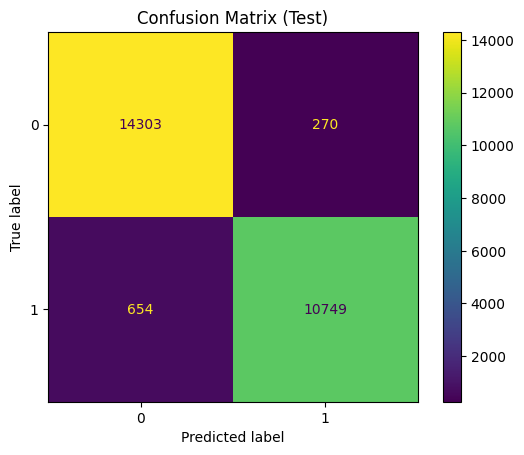

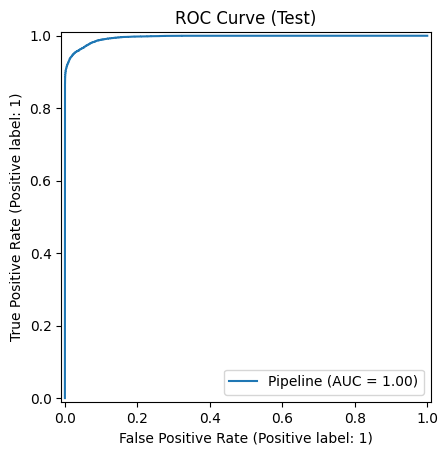

In [37]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

tuned_pipe.fit(X_full, y_full)
test_pred = tuned_pipe.predict(X_test)

print("Test metrics:")
print("  Accuracy :", accuracy_score(y_test, test_pred))
print("  Precision:", precision_score(y_test, test_pred))
print("  Recall   :", recall_score(y_test, test_pred))
print("  F1       :", f1_score(y_test, test_pred))

roc_auc = None
if hasattr(tuned_pipe, "predict_proba"):
    test_proba = tuned_pipe.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_proba)
elif hasattr(tuned_pipe, "decision_function"):
    test_score = tuned_pipe.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, test_score)

if roc_auc is not None:
    print("  ROC-AUC  :", roc_auc)

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

try:
    RocCurveDisplay.from_estimator(tuned_pipe, X_test, y_test)
    plt.title("ROC Curve (Test)")
    plt.show()
except Exception as e:
    print("Không vẽ được ROC curve:", e)

## 8) Save outputs (theo OUT_DIR)

In [38]:
import joblib
from scipy import sparse

# 8.1) Save model pipeline
model_path = ARTIFACTS_DIR / "best_pipeline.joblib"
joblib.dump(tuned_pipe, model_path)
print("Saved:", model_path)

# 8.2) Save EDA / selection tables
missing_summary.to_csv(EDA_DIR / "missing_summary.csv")
zoo_df_all.to_csv(EDA_DIR / "model_zoo_results.csv", index=False)
log_df.to_csv(EDA_DIR / "model_selection_log.csv", index=False)
print("Saved:", EDA_DIR / "missing_summary.csv")
print("Saved:", EDA_DIR / "model_zoo_results.csv")
print("Saved:", EDA_DIR / "model_selection_log.csv")

# 8.3) Save transformed features (sparse → npz, dense → npy)
pre = tuned_pipe.named_steps["preprocess"]
Xtr_feat = pre.transform(X_full)
Xte_feat = pre.transform(X_test)

if sparse.issparse(Xtr_feat):
    sparse.save_npz(FEATURES_DIR / "train_features.npz", Xtr_feat)
    sparse.save_npz(FEATURES_DIR / "test_features.npz", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npz")
    print("Saved:", FEATURES_DIR / "test_features.npz")
else:
    np.save(FEATURES_DIR / "train_features.npy", Xtr_feat)
    np.save(FEATURES_DIR / "test_features.npy", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npy")
    print("Saved:", FEATURES_DIR / "test_features.npy")

# 8.4) Feature names (nếu có)
feature_names = None
try:
    feature_names = pre.get_feature_names_out().tolist()
except Exception:
    feature_names = None

with open(FEATURES_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)

print("Saved:", FEATURES_DIR / "feature_names.json")

Saved: /content/drive/MyDrive/ML_Project/runs/exp1/artifacts/best_pipeline.joblib
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/eda_outputs/missing_summary.csv
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/eda_outputs/model_zoo_results.csv
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/eda_outputs/model_selection_log.csv
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/features/train_features.npy
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/features/test_features.npy
Saved: /content/drive/MyDrive/ML_Project/runs/exp1/features/feature_names.json
